# Static dRSA on delay-embedded neural signals

Prototype notebook: load neural rasters at 200 Hz, create delay embeddings using `TimeSeries.delay_embeddings`, run static dRSA on the delay-embedded neural signal, and plot the results. Nothing is saved to disk.

In [64]:
import os, sys, yaml
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import matplotlib.pyplot as plt
from torchvision.datasets import ImageFolder

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
PROJECT_ROOT = Path.cwd().parents[1]

with open(PROJECT_ROOT / "config.yaml", "r") as f:
    config = yaml.safe_load(f)

paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stuff_path"])

from project_specific_utils.dataloader import load_img_natraster, map_image_order_from_ann_to_monkey
from II_analyses.static_dyn import init_static_dRSA
from useful_stuff.general_utils.utils import TimeSeries, print_wise
from useful_stuff.image_processing.computational_models import get_relevant_output_layers

## Parameters

`new_fs=200` keeps the temporal resolution high. With `delay_lags=(-2, 0)`, each embedded vector contains `[t-10 ms, t-5 ms, t]` at 200 Hz.

In [86]:
cfg = SimpleNamespace(
    monkey_name="three0",
    date="250313",
    brain_area="AIT",
    folder_name="talia_20each_tizi",
    signal_RDM_metric="cosine_cnt",
    model_RDM_metric="cosine_cnt",
    model_name="vit_l_16",
    img_size=384,
    pooling="mean",
    new_fs=500,
    pkg="timm",
    delay_lags=(-20, 0),
    pad_mode=None,
    layers_to_plot=None,  # None = use the first n_layers_to_plot relevant layers
    n_layers_to_plot=24,
)

print_wise(cfg)

12:39:09 - namespace(monkey_name='three0', date='250313', brain_area='AIT', folder_name='talia_20each_tizi', signal_RDM_metric='cosine_cnt', model_RDM_metric='cosine_cnt', model_name='vit_l_16', img_size=384, pooling='mean', new_fs=500, pkg='timm', delay_lags=(-20, 0), pad_mode=None, layers_to_plot=None, n_layers_to_plot=24)


## Delay-embed raster

`TimeSeries.delay_embeddings` is implemented for 2D arrays, so this helper applies it separately to each image/trial slice `(neurons, time)` and stacks back to `(embedded_features, embedded_time, images)`.

In [87]:
def delay_embed_raster(raster: TimeSeries, lags: tuple[int, int], pad_mode: str | None = None) -> TimeSeries:
    X = raster.get_array()
    if X.ndim != 3:
        raise ValueError(f"Expected raster shape (neurons, time, images/trials), got {X.shape}")

    embedded_trials = []
    for image_idx in range(X.shape[2]):
        image_ts = TimeSeries(X[:, :, image_idx], raster.get_fs())
        embedded_trials.append(image_ts.delay_embeddings(lags, pad_mode=pad_mode).get_array())

    embedded = np.stack(embedded_trials, axis=2)
    return TimeSeries(embedded, raster.get_fs())


def delay_embedding_label(lags: tuple[int, int], pad_mode: str | None) -> str:
    pad = "valid" if pad_mode is None else pad_mode
    return f"delayemb_lags{lags[0]}to{lags[1]}_{pad}"

## Load data and create delay embeddings

In [88]:
area_rasters = load_img_natraster(
    paths,
    cfg.monkey_name,
    cfg.date,
    new_fs=cfg.new_fs,
    brain_area=cfg.brain_area,
)

print_wise(f"raw raster shape: {area_rasters.get_array().shape}, fs={area_rasters.get_fs()} Hz")

area_rasters_delay = delay_embed_raster(
    area_rasters,
    lags=cfg.delay_lags,
    pad_mode=cfg.pad_mode,
)

print_wise(f"delay-embedded raster shape: {area_rasters_delay.get_array().shape}, fs={area_rasters_delay.get_fs()} Hz")

12:39:11 - raw raster shape: (25, 150, 776), fs=500 Hz
12:39:11 - delay-embedded raster shape: (525, 130, 776), fs=500 Hz


## Match model image order to neural image order

In [89]:
dataset = ImageFolder(
    root=f"{paths['livingstone_lab']}/Stimuli/{cfg.folder_name}/",
    is_valid_file=lambda x: not x.endswith("Thumbs.db"),
    allow_empty=True,
)

idx_ord = map_image_order_from_ann_to_monkey(paths, cfg.monkey_name, cfg.date, dataset)

print_wise(f"dataset images: {len(dataset)}")
print_wise(f"image-order index length: {len(idx_ord)}")

12:39:11 - dataset images: 776
12:39:11 - image-order index length: 776


## Initialize static dRSA from delay-embedded neural signal

In [90]:
drsa_obj = init_static_dRSA(
    area_rasters_delay,
    cfg.signal_RDM_metric,
    cfg.model_RDM_metric,
)

signal_rdms = drsa_obj.get_RDM_timeseries("signal")
print_wise(f"signal RDM time series length: {len(signal_rdms)}, fs={signal_rdms.get_fs()} Hz")

12:39:11 - signal RDM time series length: 130, fs=500 Hz


## Select layers

Run this cell and inspect `task_list` if you want to set `cfg.layers_to_plot` manually.

In [91]:
task_list = get_relevant_output_layers(cfg.model_name, cfg.pkg)
layers_to_plot = cfg.layers_to_plot or task_list[:cfg.n_layers_to_plot]
delay_label = delay_embedding_label(cfg.delay_lags, cfg.pad_mode)

print_wise(f"available layers: {len(task_list)}")
print_wise(f"selected layers: {layers_to_plot}")
task_list

12:39:11 - available layers: 24
12:39:11 - selected layers: ['blocks.0.mlp.fc2', 'blocks.1.mlp.fc2', 'blocks.2.mlp.fc2', 'blocks.3.mlp.fc2', 'blocks.4.mlp.fc2', 'blocks.5.mlp.fc2', 'blocks.6.mlp.fc2', 'blocks.7.mlp.fc2', 'blocks.8.mlp.fc2', 'blocks.9.mlp.fc2', 'blocks.10.mlp.fc2', 'blocks.11.mlp.fc2', 'blocks.12.mlp.fc2', 'blocks.13.mlp.fc2', 'blocks.14.mlp.fc2', 'blocks.15.mlp.fc2', 'blocks.16.mlp.fc2', 'blocks.17.mlp.fc2', 'blocks.18.mlp.fc2', 'blocks.19.mlp.fc2', 'blocks.20.mlp.fc2', 'blocks.21.mlp.fc2', 'blocks.22.mlp.fc2', 'blocks.23.mlp.fc2']


['blocks.0.mlp.fc2',
 'blocks.1.mlp.fc2',
 'blocks.2.mlp.fc2',
 'blocks.3.mlp.fc2',
 'blocks.4.mlp.fc2',
 'blocks.5.mlp.fc2',
 'blocks.6.mlp.fc2',
 'blocks.7.mlp.fc2',
 'blocks.8.mlp.fc2',
 'blocks.9.mlp.fc2',
 'blocks.10.mlp.fc2',
 'blocks.11.mlp.fc2',
 'blocks.12.mlp.fc2',
 'blocks.13.mlp.fc2',
 'blocks.14.mlp.fc2',
 'blocks.15.mlp.fc2',
 'blocks.16.mlp.fc2',
 'blocks.17.mlp.fc2',
 'blocks.18.mlp.fc2',
 'blocks.19.mlp.fc2',
 'blocks.20.mlp.fc2',
 'blocks.21.mlp.fc2',
 'blocks.22.mlp.fc2',
 'blocks.23.mlp.fc2']

## Compute and plot static dRSA

Results stay in memory as `drsa_by_layer`; nothing is saved.

12:39:11 - computed static dRSA for blocks.0.mlp.fc2
12:39:12 - computed static dRSA for blocks.1.mlp.fc2
12:39:12 - computed static dRSA for blocks.2.mlp.fc2
12:39:12 - computed static dRSA for blocks.3.mlp.fc2
12:39:12 - computed static dRSA for blocks.4.mlp.fc2
12:39:12 - computed static dRSA for blocks.5.mlp.fc2
12:39:12 - computed static dRSA for blocks.6.mlp.fc2
12:39:12 - computed static dRSA for blocks.7.mlp.fc2
12:39:13 - computed static dRSA for blocks.8.mlp.fc2
12:39:13 - computed static dRSA for blocks.9.mlp.fc2
12:39:13 - computed static dRSA for blocks.10.mlp.fc2
12:39:13 - computed static dRSA for blocks.11.mlp.fc2
12:39:13 - computed static dRSA for blocks.12.mlp.fc2
12:39:13 - computed static dRSA for blocks.13.mlp.fc2
12:39:13 - computed static dRSA for blocks.14.mlp.fc2
12:39:14 - computed static dRSA for blocks.15.mlp.fc2
12:39:14 - computed static dRSA for blocks.16.mlp.fc2
12:39:14 - computed static dRSA for blocks.17.mlp.fc2
12:39:14 - computed static dRSA for bl

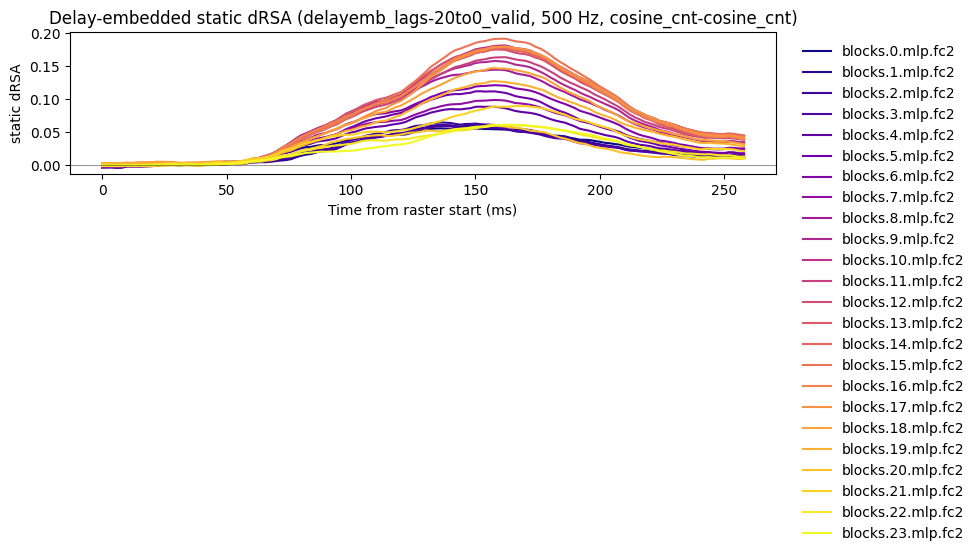

In [92]:
def compute_static_dRSA_delay_embedded(layer_name: str):
    feats_filename = Path(paths["data_path"]) / "models" / (
        f"{cfg.folder_name}_{cfg.model_name}_{cfg.img_size}_"
        f"{layer_name}_features_{cfg.pooling}pool.npz"
    )
    features = np.load(feats_filename)["arr_0"][:, idx_ord]

    drsa_obj.compute_RDM(features, "model")
    drsa = drsa_obj.compute_static_dRSA()
    print_wise(f"computed static dRSA for {layer_name}")
    return drsa


drsa_by_layer = {
    layer_name: compute_static_dRSA_delay_embedded(layer_name)
    for layer_name in layers_to_plot
}

fs = drsa_obj.get_RDM_timeseries("signal").get_fs()
n_timepoints = len(drsa_obj.get_RDM_timeseries("signal"))
time_ms = np.arange(n_timepoints) / fs * 1000

cmap = plt.cm.plasma
colors = cmap(np.linspace(0, 1, len(drsa_by_layer)))

fig, ax = plt.subplots(figsize=(10, 4))
for color, (layer_name, drsa) in zip(colors, drsa_by_layer.items()):
    ax.plot(time_ms, drsa.get_array(), label=layer_name, color=color)

ax.axhline(0, color="k", linewidth=0.8, alpha=0.4)
ax.set_xlabel("Time from raster start (ms)")
ax.set_ylabel("static dRSA")
ax.set_title(
    f"Delay-embedded static dRSA ({delay_label}, {cfg.new_fs} Hz, "
    f"{cfg.signal_RDM_metric}-{cfg.model_RDM_metric})"
)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
fig.tight_layout()
plt.show()